In [7]:
import pandas as pd          # veri okuma ve işleme
import numpy as np           # matematiksel işlemler
import matplotlib.pyplot as plt  # grafik çizme
import seaborn as sns        # daha güzel grafikler

pd.set_option('display.max_columns', None)  # tüm sütunları göster

In [8]:
# CSV dosyasını okuyup df adlı değişkene atıyoruz. df = DataFrame yani bir tablo.
df = pd.read_csv('../data/telco_customer_churn.csv')
print(df.shape)  # kaç satır, kaç sütun
df.head()        # ilk 5 satırı göster

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Her sütunun veri tipini ve kaç dolu değer olduğunu gösterir.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
# Her sütunda kaç tane boş (null) değer var?
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


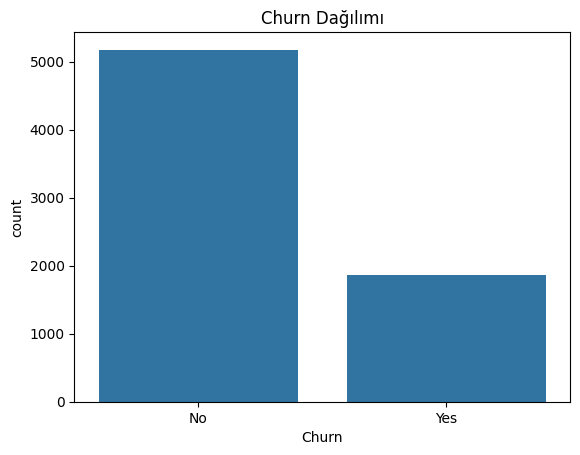

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [11]:
# Kaç müşteri ayrılmış, kaçı kalmış? Grafik + yüzde olarak gösterir.
sns.countplot(x='Churn', data=df)
plt.title('Churn Dağılımı')
plt.show()
print(df['Churn'].value_counts(normalize=True) * 100)

In [12]:
# TotalCharges sütunu sayı olması gerekirken metin olarak gelmiş, sayıya çeviriyoruz, bozuk olanlar NaN (boş) olur.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


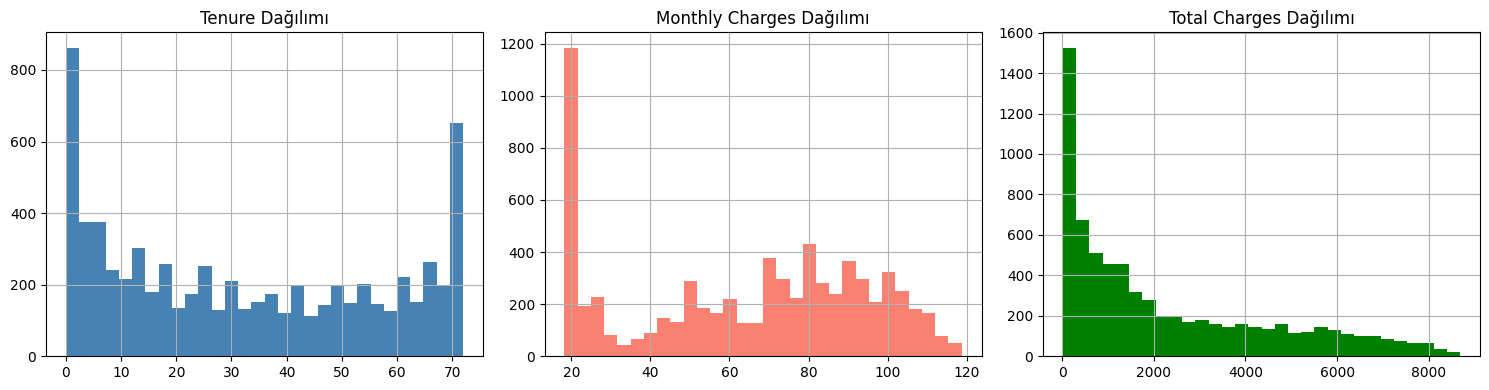

In [13]:
# 3 sayısal sütunun histogramını çiz, verinin nasıl dağıldığını anlamak için.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['tenure'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Tenure Dağılımı')

df['MonthlyCharges'].hist(ax=axes[1], bins=30, color='salmon')
axes[1].set_title('Monthly Charges Dağılımı')

df['TotalCharges'].hist(ax=axes[2], bins=30, color='green')
axes[2].set_title('Total Charges Dağılımı')

plt.tight_layout()
plt.show()

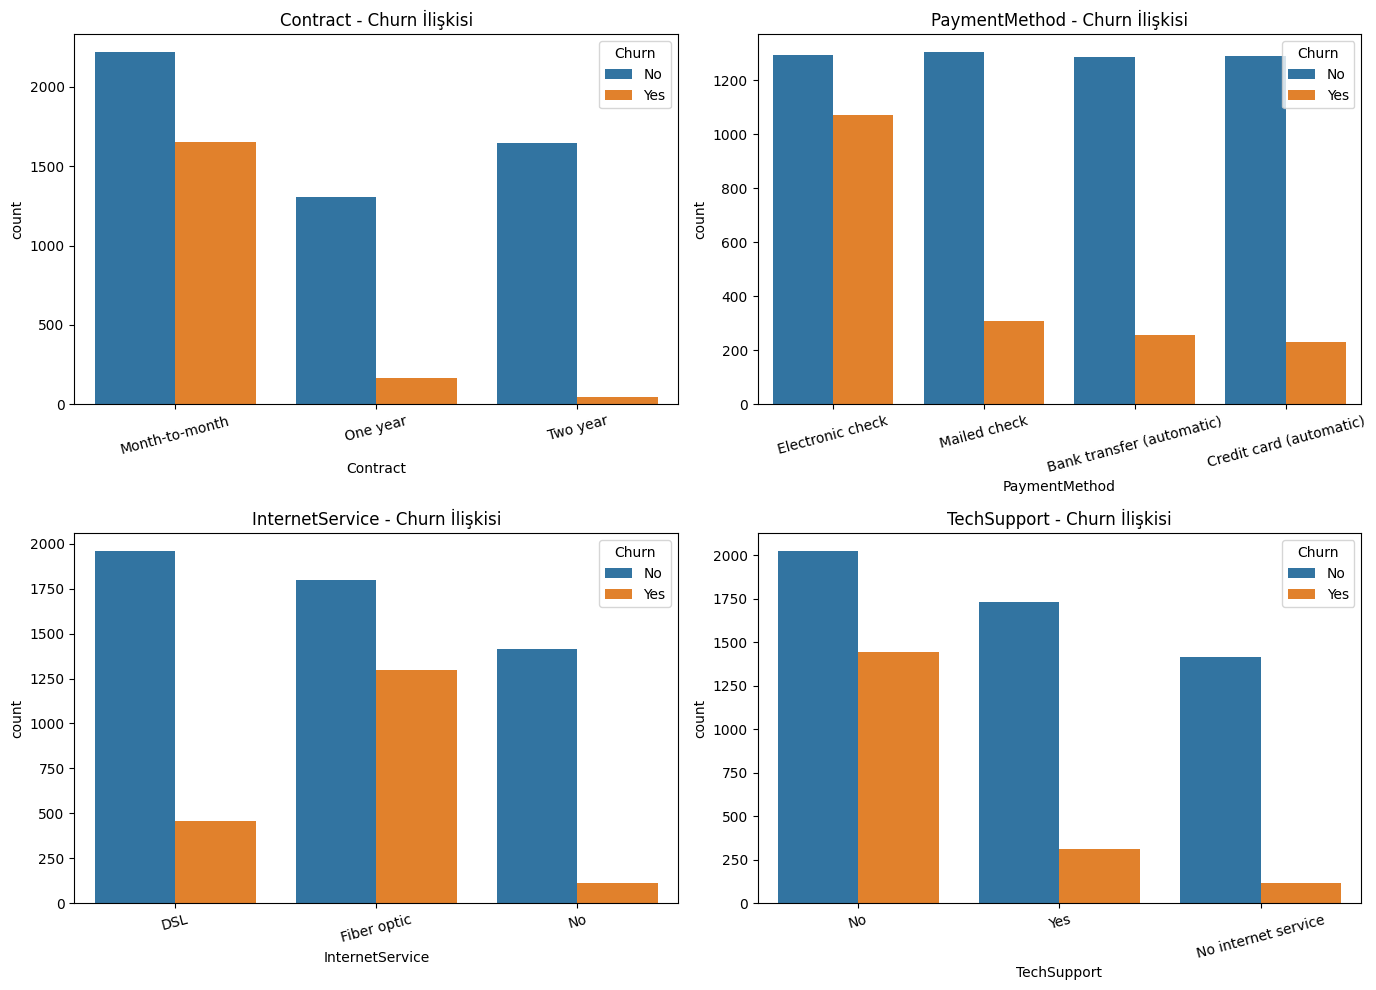

In [14]:
# Sözleşme tipi, ödeme yöntemi gibi kategorilere göre churn oranı nasıl değişiyor?
kategorik = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), kategorik):
    sns.countplot(x=col, hue='Churn', data=df, ax=ax)
    ax.set_title(f'{col} - Churn İlişkisi')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [15]:
# 6. hücrede oluşan 11 boş satırı siliyoruz.
df = df.dropna(subset=['TotalCharges'])
print(df.shape)

(7032, 21)


In [16]:
# Model sayılarla çalışır, metinlerle değil.
# Yes/No gibi değerleri 1/0'a çeviriyoruz. 
df = df.drop(columns=['customerID'])  # ID sütunu işe yaramaz

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'No internet service': 0, 
                           'No phone service': 0})

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [17]:
# Birden fazla kategorisi olan sütunlar için her kategoriyi ayrı bir sütuna dönüştürüyoruz.
# Örneğin Contract sütunu Month-to-month, One year, Two year değerlerini alıyor.
# Bunu 3 ayrı 0/1 sütununa çeviriyoruz.
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService',
                                  'Contract', 'PaymentMethod'], drop_first=True)
print(df.shape)
df.head()

(7032, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,0,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,1,0,1,0,0,0,0,56.95,1889.50,0,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,1,0,0,0,0,1,53.85,108.15,1,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,1,0,1,1,0,0,0,42.30,1840.75,0,True,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,0,0,1,70.70,151.65,1,False,False,True,False,False,False,False,True,False


In [18]:
# One-Hot Encoding True/False üretir, bunu 0/1'e çeviriyoruz.
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
print(df.shape)
df.head()

(7032, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,0,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,0,0,0,56.95,1889.50,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,0,0,0,42.30,1840.75,0,1,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,1,70.70,151.65,1,0,0,1,0,0,0,0,1,0


In [19]:
# X = modelin bakacağı özellikler (input).
# y = tahmin edeceğimiz şey (output)
X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y dağılımı:\n", y.value_counts())

X shape: (7032, 24)
y dağılımı:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [20]:
# Veriyi ikiye bölüyoruz. %80 ile modeli eğitiyoruz, %20 ile test ediyoruz. Modelin hiç görmediği veriyle test etmek önemli.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5625, 24)
Test: (1407, 24)


In [21]:
# Sayısal sütunlar farklı ölçeklerde. tenure 0-72 arası, MonthlyCharges 18-118 arası.
# Modelin adil değerlendirme yapması için hepsini aynı ölçeğe getiriyoruz.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme tamamlandı!")

Ölçeklendirme tamamlandı!


In [22]:
# 3 farklı algoritma deniyoruz. En iyisini seçeceğiz.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

modeller = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

sonuclar = {}

for isim, model in modeller.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    sonuclar[isim] = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred), 4)
    }

sonuc_df = pd.DataFrame(sonuclar).T
print(sonuc_df)

                     Accuracy  F1 Score  ROC-AUC
Logistic Regression    0.8038    0.6091   0.7308
Random Forest          0.7910    0.5625   0.6999
XGBoost                0.7783    0.5679   0.7048


In [23]:
# En yüksek ROC-AUC skoruna sahip modeli .pkl dosyası olarak kaydediyoruz.
# Bu dosya eğitilmiş modelin ta kendisi. FastAPI bunu okuyup tahmin yapacak.
import joblib

en_iyi = sonuc_df['ROC-AUC'].idxmax()
print(f"En iyi model: {en_iyi}")

en_iyi_model = modeller[en_iyi]

joblib.dump(en_iyi_model, '../models/model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print("Model kaydedildi!")

En iyi model: Logistic Regression
Model kaydedildi!
